### Se pide, usando regresión lineal:

Dibujar con una línea la relación que hay entre la altura y la edad de los alumnos de esta clase. ¿Es una buena técnica para este tipo de problemas? Demuéstralo antes de entrenar un modelo con un análisis descriptivo.

In [2]:
lista_alumnos = [("Leonardo S", 24, 1.82), 
                 ("Piero T", 25, 1.71), 
                 ("Marta B", 35, 1.66), 
                 ("Silvia P", 37, 1.63), 
                 ("Faro Z", 29, 1.90), 
                 ("Miguel N", 27, 1.80), 
                 ("Alejandro M", 28, 1.70), 
                 ("Cristina M", 32, 1.60), 
                 ("Francisco P", 36, 1.74), 
                 ("Jorge D", 45, 1.72), 
                 ("Jesús L", 41, 1.65), 
                 ("Marta G", 30, 1.65), 
                 ("Jennifer S", 40, 1.60), 
                 ("Diego I", 39, 1.80), 
                 ("Antonio C", 23, 1.77), 
                 ("Juan M", 32, 1.75), 
                 ("David S", 27, 1.70), 
                 ("Antonio J", 34, 1.80), 
                 ("Carlos H", 27, 1.77), 
                 ("Erik U", 28, 1.70), 
                 ("Marcos L", 35, 1.80)] 

In [3]:
# importo librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# creo un dataframe con la lista de alumnos
alumnos = pd.DataFrame(lista_alumnos, columns=["nombre", "edad", "altura"])
alumnos

,nombre,edad,altura
0,Leonardo S,24,1.82
1,Piero T,25,1.71
2,Marta B,35,1.66
3,Silvia P,37,1.63
4,Faro Z,29,1.90
5,Miguel N,27,1.80
6,Alejandro M,28,1.70
7,Cristina M,32,1.60
8,Francisco P,36,1.74
9,Jorge D,45,1.72


In [5]:
# muestro la información del dataframe
alumnos.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   nombre  21 non-null     str    
 1   edad    21 non-null     int64  
 2   altura  21 non-null     float64
dtypes: float64(1), int64(1), str(1)
memory usage: 636.0 bytes


In [6]:
# muestro las estadísticas del dataframe
alumnos.describe()

,edad,altura
count,21.000000,21.000000
mean,32.095238,1.727143
std,6.081980,0.079003
min,23.000000,1.600000
25%,27.000000,1.660000
50%,32.000000,1.720000
75%,36.000000,1.800000
max,45.000000,1.900000


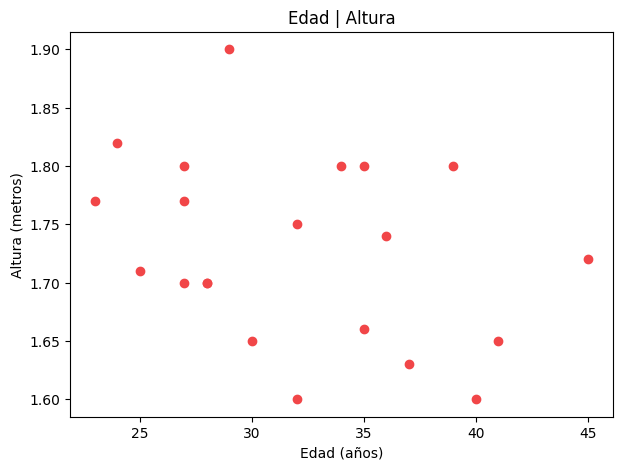

In [7]:
# creo un scatter plot para visualizar la relación entre edad y altura
plt.figure(figsize=(7, 5))
plt.scatter(alumnos["edad"], alumnos["altura"], color="#f14648")
plt.xlabel("Edad (años)")
plt.ylabel("Altura (metros)")
plt.title("Edad | Altura");

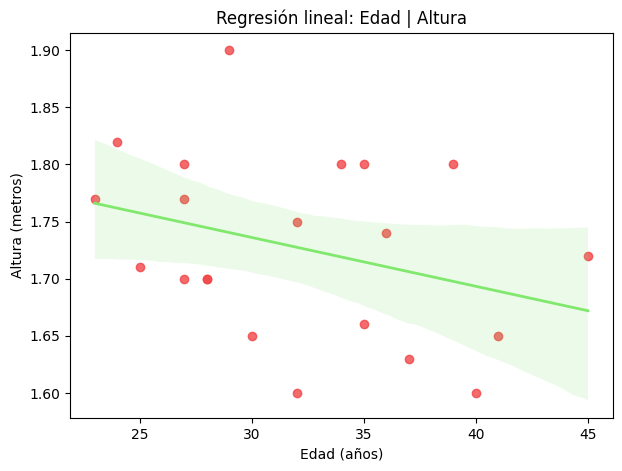

In [8]:
# creo un scatter plot con una línea de regresión para visualizar la relación entre edad y altura
plt.figure(figsize=(7, 5))
sns.regplot(x="edad", y="altura", data=alumnos,
            scatter_kws={"color": "#f14648"},
            line_kws={"color": "#81E86E", "linewidth": 2})
plt.xlabel("Edad (años)")
plt.ylabel("Altura (metros)")
plt.title("Regresión lineal: Edad | Altura");

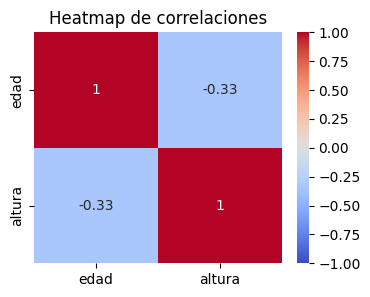

In [9]:
# creo un heatmap para visualizar la correlación entre edad y altura
plt.figure(figsize=(4, 3))
sns.heatmap(alumnos[["edad", "altura"]].corr(), annot=True, cmap="coolwarm", vmin=-1)
plt.title("Heatmap de correlaciones");

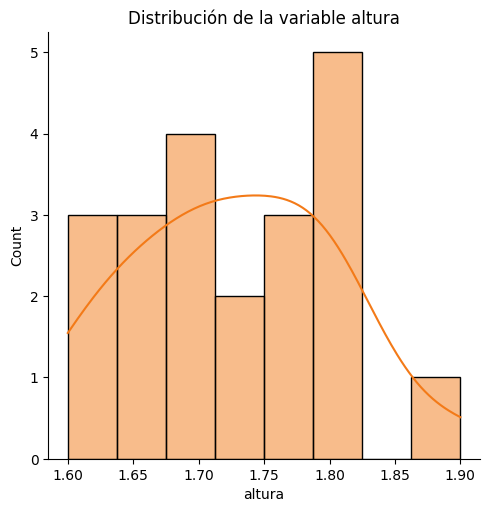

In [10]:
# creo un histograma para visualizar la distribución de la variable alturas
sns.displot(alumnos["altura"], kde=True, bins=8, color="#F37A18")
plt.title("Distribución de la variable altura");

#### CONCLUSIÓN

#### Viendo las estadísticas iniciales, con describe(), se observa que la altura media es 1,73 metros con una desviación estándar muy pequeña (0,079), lo que indica poca variabilidad. El scatter con línea de regresión y el heatmap confirman poca correlación entre edad y altura. Por tanto, la regresión lineal no es una buena técnica para este problema, ya que la edad no explica la altura de los alumnos.

### Entrena un modelo de regresión lineal

In [11]:
# divido el dataframe en variables predictoras (X) y variable objetivo (y)
X = alumnos[["edad"]]
y = alumnos["altura"]

In [12]:
# importo la función train_test_split para dividir el dataset en conjunto de entrenamiento y conjunto de prueba
from sklearn.model_selection import train_test_split

# divido el dataset en conjunto de entrenamiento (80%) y conjunto de prueba (20%), con una semilla = 11
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

In [13]:
# muestro el tamaño de cada conjunto
print(f"El tamaño de X train es {X_train.shape}")
print(f"El tamaño de y train es {y_train.shape}")
print(f"El tamaño de X test es {X_test.shape}")
print(f"El tamaño de y test es {y_test.shape}")

El tamaño de X train es (16, 1)
El tamaño de y train es (16,)
El tamaño de X test es (5, 1)
El tamaño de y test es (5,)


In [14]:
# importo la clase StandardScaler para escalar las variables predictoras
from sklearn.preprocessing import StandardScaler

escalado = StandardScaler() # creo un objeto de la clase StandardScaler

escalado.fit(X_train) # ajusto el escalado a los datos de entrenamiento

X_train_escalado = escalado.transform(X_train) # transformo los datos de entrenamiento con el escalado ajustado

X_test_escalado = escalado.transform(X_test) # transformo los datos de prueba con el mismo escalado


In [15]:
from sklearn.linear_model import LinearRegression # importo la clase LinearRegression 

# creo un modelo de regresión lineal y lo ajusto a los datos de entrenamiento escalados
modelo_alumnos = LinearRegression()
modelo_alumnos.fit(X_train_escalado, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
# hago predicciones con el modelo ajustado sobre los datos de prueba escalados
predicciones = modelo_alumnos.predict(X_test_escalado)
predicciones

array([1.71878785, 1.74763055, 1.70725076, 1.74474628, 1.7332092 ])

In [18]:
# Para poder predecir una altura a partir de la edad

edad = escalado.transform([[30]])
res = modelo_alumnos.predict(edad)
print(res)

[1.73897774]


c:\Users\rober\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


### ¿Qué error se comete? Calcula los errores que está cometiendo tu modelo de forma manual con python. Aparte, usa las métricas de sklearn MAE, MAPE, MSE y el RMSE.

In [54]:
import numpy as np

# calculo las métricas de forma manual
mae_manual = abs(y_test - predicciones).mean() # promedio de los valores absolutos de las diferencias entre los valores reales y las predicciones
mse_manual = ((y_test - predicciones) ** 2).mean() # promedio de los valores de las diferencias al cuadrado entre los valores reales y las predicciones
mape_manual = abs((y_test - predicciones) / y_test).mean() # promedio de los valores absolutos de las diferencias relativas entre los valores reales y las predicciones
rmse_manual = np.sqrt(mse_manual) # raíz cuadrada del MSE

print(f"El MAE es: {mae_manual}")
print(f"El MSE es: {mse_manual}")  
print(f"El MAPE es: {mape_manual}")
print(f"El RMSE es: {rmse_manual}") 

El MAE es: 0.05198902837852093
El MSE es: 0.0032375303207435443
El MAPE es: 0.030835745601908056
El RMSE es: 0.05689929982647892


In [55]:
# importo las funciones para calcular las métricas de evaluación
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

In [57]:
# calculo las métricas utilizando las funciones de sklearn
mae = mean_absolute_error(y_test, predicciones)
mse = mean_squared_error(y_test, predicciones)
mape = mean_absolute_percentage_error(y_test, predicciones)
rmse = np.sqrt(mse)

In [58]:
# imprimo las métricas calculadas
print(f"El MAE es: {mae}")
print(f"El MSE es: {mse}")
print(f"El MAPE es: {mape}")
print(f"El RMSE es: {rmse}")

El MAE es: 0.05198902837852093
El MSE es: 0.0032375303207435443
El MAPE es: 0.030835745601908056
El RMSE es: 0.05689929982647892


#### MAE = 0.052: el modelo se equivoca de media 5.2 cm en cada predicción.
#### MSE = 0.003: penaliza más los errores grandes al elevarlos al cuadrado, por eso el número es tan pequeño.
#### MAPE = 0.031: el modelo se equivoca un 3.1 % respecto al valor real de la altura. Parece poco, pero sobre un rango de solo 30 cm (1,60 metros a 1,90 metros) es una diferencia importante.
#### RMSE = 0.057: es muy similar al MAE.

#### Conclusión: con errores de entre 5 y 6 cm sobre una variable que varía alrededor de 30 cm, el modelo no tiene capacidad predictiva real. Y esto confirma lo que ya demostraba el análisis descriptivo: la edad no explica la altura.